**Import Libraries**

In [6]:
!pip install gensim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import nltk
from nltk.corpus import stopwords
from gensim.models import FastText
from sklearn.decomposition import PCA

 **Load Dataset**

In [7]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kanchana1990/biomedical-research-abstracts-20242026")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'biomedical-research-abstracts-20242026' dataset.
Path to dataset files: /kaggle/input/biomedical-research-abstracts-20242026


In [8]:
import os
import pandas as pd

# Let's first inspect the files in the downloaded directory to find the correct CSV file name.
print("Files in the downloaded dataset directory:", os.listdir(path))

# The original code was looking for 'bbc-text.csv', which is incorrect for this dataset.
# Based on the dataset name 'biomedical-research-abstracts-20242026',
# the correct CSV file name is 'biomedical_research_abstracts_2024_2026.csv'.
csv_file_name = 'biomedical_research_abstracts_2024_2026.csv'

# Construct the full path to the CSV file.
full_csv_path = os.path.join(path, csv_file_name)

df = pd.read_csv(full_csv_path)
df.head()

Files in the downloaded dataset directory: ['biomedical_research_abstracts_2024_2026.csv']


,pmid,title,abstract,abstract_words,journal,pub_year,pub_month,pub_month_num,month_year,doi,authors_count,country,research_type,keywords,major_topic,language,open_access
0,41869676,"The genome sequence of the bloodfluke planorb,...",We present a genome assembly from an individua...,57,Wellcome open research,2024,Unknown,0,Unknown-2024,10.12688/wellcomeopenres.22819.2,7,UK,Journal Article,NaN,NaN,eng,True
1,41841041,An exploratory study of critical incidents wit...,Leadership changes within public organizations...,250,F1000Research,2024,Unknown,0,Unknown-2024,10.12688/f1000research.142942.2,4,Indonesia,Journal Article,Leadership; Humans; Anxiety; Organizational In...,Leadership,eng,True
2,41797731,From Mary Shelley to Netflix: a Pan-European p...,Scientific knowledge of the human brain has ca...,244,Frontiers in neuroscience,2024,Unknown,0,Unknown-2024,10.3389/fnins.2024.1278640,2,Spain,Journal Article,NaN,NaN,eng,True
3,41726542,Improving electronic health record processing ...,Large language models (LLMs) excel in natural ...,134,AMIA ... Annual Symposium proceedings. AMIA Sy...,2024,Unknown,0,Unknown-2024,NaN,4,USA,Journal Article,Natural Language Processing; Electronic Health...,Natural Language Processing,eng,True
4,41726541,Developing a User-Centered Mobile Application ...,This study is part of the OsteoPorotic fracTur...,136,AMIA ... Annual Symposium proceedings. AMIA Sy...,2024,Unknown,0,Unknown-2024,NaN,13,USA,Journal Article,Mobile Applications; Humans; Skilled Nursing F...,Mobile Applications,eng,True


** Text Preprocessing**

In [10]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

def preprocess_text(text):
  # Lowercase
  text = text.lower()
  # Remove special character
  text = re.sub(r'[^a-zA-Z\s]', '', text)
  # Tokenize and remove stopwords
  words = nltk.word_tokenize(text)
  stop_words = set(stopwords.words('english'))
  words = [w for w in words if w not in stop_words]
  return words

df['tokenized_text'] = df['abstract'].apply(preprocess_text)
tokenized_data = df['tokenized_text'].tolist()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [12]:
import os
import numpy as np # Ensure numpy is imported for np.asarray

def load_glove(file_path):
    embeddings = {}
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            for line in f:
                values = line.split()
                word = values[0]
                vector = np.asarray(values[1:], dtype='float32')
                embeddings[word] = vector
    except FileNotFoundError:
        print(f"Error: GloVe file '{file_path}' not found. Please ensure it is downloaded and extracted.")
        return None # Return None if file not found
    return embeddings

glove_path = "glove.6B.100d.txt"

# Check if the GloVe file exists, if not, download and unzip it
if not os.path.exists(glove_path):
    print(f"'{glove_path}' not found. Downloading GloVe embeddings...")
    # Using shell commands with ! in Jupyter/Colab
    !wget -nc http://nlp.stanford.edu/data/glove.6B.zip # -nc for no-clobber, avoids re-downloading
    !unzip -o glove.6B.zip # -o for overwrite without prompt if file exists

glove_embeddings = load_glove(glove_path)

if glove_embeddings is not None:
    print("GloVe loaded")
else:
    print("Failed to load GloVe embeddings.")

'glove.6B.100d.txt' not found. Downloading GloVe embeddings...
--2026-04-13 06:41:38--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2026-04-13 06:41:38--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2026-04-13 06:41:38--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862

**GloVe similar words manually (cosine similarity)**

In [13]:
from numpy.linalg import norm

def cosine_similarity(a, b):
    return np.dot(a, b) / (norm(a) * norm(b))

**Example comparison**

In [14]:
word1, word2 = "market", "economy"

if word1 in glove_embeddings and word2 in glove_embeddings:
    sim = cosine_similarity(glove_embeddings[word1], glove_embeddings[word2])
    print("GloVe Similarity:", sim)

GloVe Similarity: 0.712294


**Train FastText Model**

In [15]:

fasttext_model = FastText(
    sentences=tokenized_data,
    vector_size=100,
    window=5,
    min_count=2
)

print("FastText model trained")

FastText model trained


**FastText Similar Words**

In [16]:
print("\nFastText Similar Words:")
print(fasttext_model.wv.most_similar("market"))


FastText Similar Words:
[('markets', 0.8642401099205017), ('freshmarket', 0.8435792326927185), ('marketready', 0.8393409848213196), ('marketplace', 0.8103905916213989), ('marketscan', 0.7818661332130432), ('premarket', 0.7587524652481079), ('marketplaces', 0.7512953877449036), ('marketdriven', 0.7445974349975586), ('supermarket', 0.739397406578064), ('marketing', 0.7212430834770203)]


**Misspelled** Word Test

In [17]:
print("\nMisspelled Word Test (FastText):")
print(fasttext_model.wv["goverment"])  # works


Misspelled Word Test (FastText):
[-1.2897290e+00 -1.2571518e+00 -4.7500086e-01 -7.3102623e-01
  1.2045789e+00  7.3500675e-01  6.1724561e-01  9.7929960e-01
 -1.8311188e+00  4.9808819e-04 -1.4972271e+00  2.4926913e+00
  9.0751827e-01  1.9148241e+00  1.6688653e+00 -1.8026783e+00
  1.0585648e+00  1.0497032e+00 -1.4812473e+00 -1.0620639e+00
  1.2217336e+00 -1.1797042e-01 -6.9998163e-01  6.4810181e-01
 -2.3820004e+00 -4.4981930e-01 -5.5842626e-01  1.8329828e+00
 -4.0385976e-02  1.2613925e+00  1.1063426e+00  1.4276301e+00
 -1.8152504e+00  1.1044850e+00  3.0592437e+00 -2.6421106e-01
 -1.9870050e+00 -8.4595844e-02  8.5173392e-01 -1.3782352e+00
 -1.9333717e-01  6.6229910e-01  2.9694910e+00 -5.2767879e-01
  5.8935839e-01  1.7041820e+00 -2.3788159e+00  6.2132728e-01
 -6.2716758e-01  1.4321645e+00  6.0825986e-01 -6.1501861e-02
  1.5756414e+00  8.0857050e-01 -9.3903655e-01  4.3979630e-01
  2.7324979e+00  1.3262037e+00  5.0782615e-01  1.8782388e+00
  1.0969472e+00 -5.3480197e-02  1.0617385e+00  3.26

**Visualization (PCA)**

In [20]:
def plot_embeddings(model, title):
    words = list(model.wv.index_to_key)[:10]
    vectors = model.wv[words]

    pca = PCA(n_components=2)
    result = pca.fit_transform(vectors)

    plt.figure(figsize=(8,6))
    plt.scatter(result[:,0], result[:,1])

    for i, word in enumerate(words):
        plt.annotate(word, xy=(result[i,0], result[i,1]))

    plt.title(title)
    plt.show()


**Plot FastText embeddings**

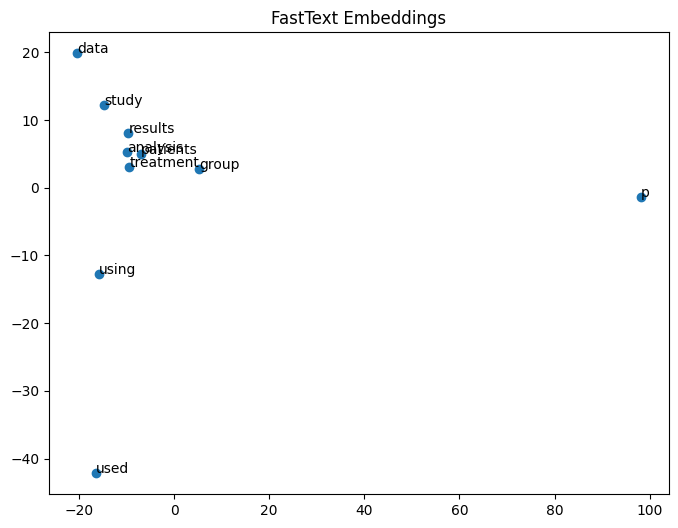

In [21]:
plot_embeddings(fasttext_model, "FastText Embeddings")